# Clustering de salarios

En este notebook se toman los resultados que se produjeron cuando se corre el código y se exploran. El notebook está creado a los efectos de la exploración de los resultados y la visualización

# Preparación

In [1]:
import os
import sys

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

print(f"Raíz del proyecto añadida al path: {project_root}")
from constantes import *
import pandas as pd
import geopandas as gpd
import numpy as np
from matplotlib import pyplot as plt
from datos.scripts_preproceso.procesamiento_sal import Salarios
import pickle
cant_peris = 108

%matplotlib inline
%load_ext autoreload
%autoreload 2
#%load_ext rpy2.ipython

Raíz del proyecto añadida al path: d:\Archivos\Codigos\clustering espacial


In [2]:
import SDEC.deep_cluster
from keras.utils import get_custom_objects

get_custom_objects()['ClusteringLayer'] = SDEC.deep_cluster.ClusteringLayer

In [3]:
DIR_RDOS = os.path.join(DIR_RESULTADOS, 'salarios')
with open(DIR_RDOS+"/resultados_masa_puestos2.pkl", "rb") as f:
    resultados = pickle.load(f)

parametros = resultados["parametros"]
resultados = resultados["resultados"]

In [4]:
parametros

{'variables': ['masa_cer', 'puestos'],
 'poblacion': 'personas',
 'n_clusters_d': 10,
 'n_clusters_h': 50,
 'semilla': 42,
 'matriz': 4}

In [5]:
proc = Salarios()
prop_st = proc.preparar_datos(parametros['variables'], parametros['poblacion'])
geo = proc.geo

c:\Users\Pablo\miniconda3\envs\sdec\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: driver ESRI Shapefile does not support open option INDEX
  return ogr_read(


# Procesado de datos

In [6]:
from SDEC import sumacuadrados as suc
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

[[1. 1.]
 [1. 1.]] 995436.1348078178 1.6963664905872638e-26 0.029818456260630954


In [7]:
X1 = prop_st[:, :cant_peris]
X2 = prop_st[:, cant_peris:]

n = 20
# Evaluar la reconstrucción del autoencoder
loss = resultados[n].autoencoder.evaluate([X1, X2], prop_st, verbose=1)
print("Pérdida de reconstrucción (cosine_similarity):", loss)

# Obtener embeddings del encoder
embeddings = resultados[n].encoder.predict([X1, X2])




labels = resultados[n].y_pred  # O el atributo correspondiente
print("Silhouette:", silhouette_score(embeddings, labels))
print("Calinski-Harabasz:", calinski_harabasz_score(embeddings, labels))
print("Davies-Bouldin:", davies_bouldin_score(embeddings, labels))

print(suc.SSD(embeddings, labels))

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: -0.1772  
Pérdida de reconstrucción (cosine_similarity): -0.17719708383083344
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Silhouette: 0.37380358576774597
Calinski-Harabasz: 202.89503305398418
Davies-Bouldin: 2.5237386419686705
{'TSS': np.float32(263662.88), 'WSS': np.float32(1380.2395), 'BSS': np.float32(236058.08), 'RBTSS': np.float32(0.89530265)}


In [8]:
X1 = prop_st[:, :cant_peris]
X2 = prop_st[:, cant_peris:]

rdos = {}

for k in resultados.keys():
    R = {}
    # evaluar la agrupación real
    r = suc.SSD(prop_st, resultados[k].y_pred)
    R['SSD total'] = r['RBTSS']
    # Evaluar la agrupación en los encoders
    # Evaluar la reconstrucción del autoencoder
    loss = resultados[k].autoencoder.evaluate([X1, X2], prop_st, verbose=False)
    R['Reconstrucción'] = loss
    # Obtener embeddings del encoder
    embeddings = resultados[k].encoder.predict([X1, X2])
    # Calcular métricas de clustering
    labels = resultados[k].y_pred  # O el atributo correspondiente
    R["Silhouette"] = silhouette_score(embeddings, labels)
    R["Calinski-Harabasz"] =  calinski_harabasz_score(embeddings, labels)
    R["Davies-Bouldin"] =  davies_bouldin_score(embeddings, labels)
    r = suc.SSD(embeddings, labels)
    R['SSD embeddings'] = r['RBTSS']
    rdos[k] = R


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
16/16 ━━━━━━━━━━━━━━━

<Axes: >

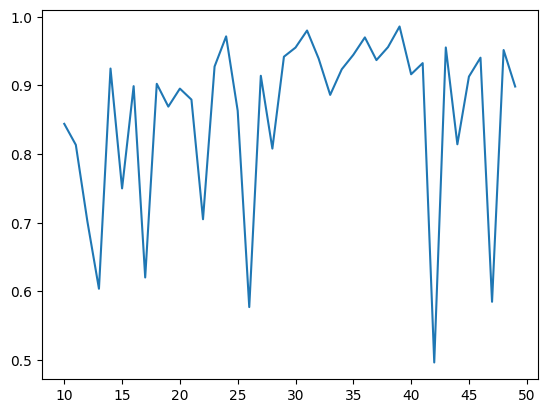

In [9]:
rdos = pd.DataFrame(rdos).T
rdos['SSD embeddings'].plot()

In [10]:
#rdos.to_excel("salarios/resultados/rdos_masa_puestos.xlsx")

In [11]:
sc = resultados[20]
r = suc.SSD(prop_st, sc.y_pred)
r

{'TSS': np.float64(117947.42036923501),
 'WSS': np.float64(5145.455290756201),
 'BSS': np.float64(15038.314554110984),
 'RBTSS': np.float64(0.12750015648526658)}

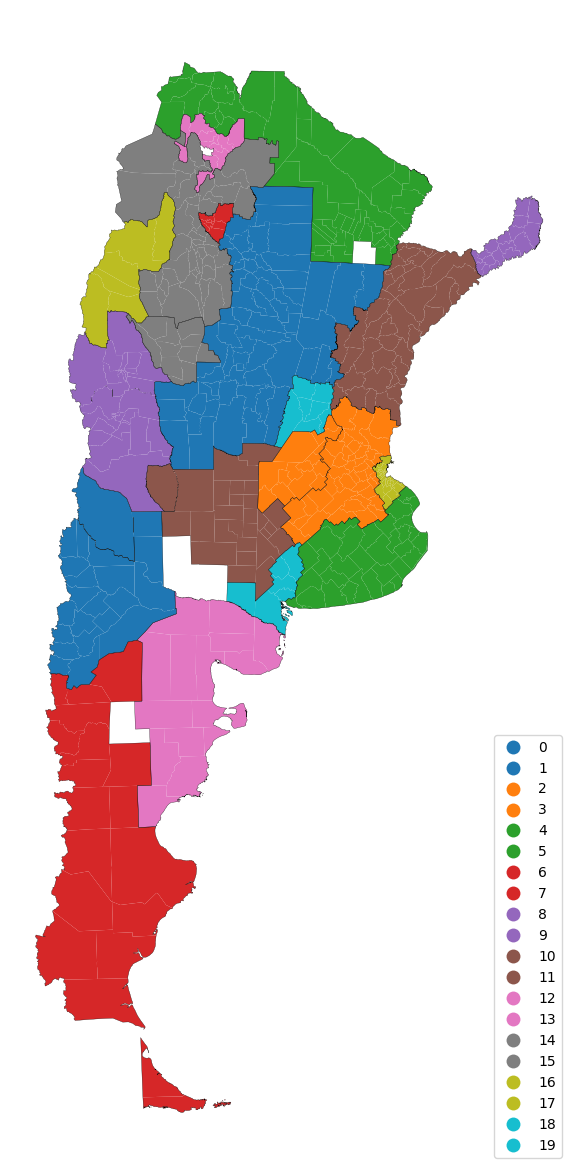

In [12]:
import colorcet as cc
geo_prop = gpd.GeoDataFrame(prop_st,columns =  np.array(range(cant_peris*2), str), geometry = geo.reset_index().geometry)
#base = geo_prop.boundary.plot(figsize = (10,8), color = 'black', edgecolor = 'black', linewidth = 0.2)
geos = []

for i in np.unique(sc.y_pred):
    g = geo[sc.y_pred == i].union_all()
    geos.append(g)

geos = gpd.GeoSeries(geos)
base = geos.boundary.plot(figsize = (10,15), color = 'black', edgecolor = 'black', linewidth = 0.2)
graf = geo_prop.plot(sc.y_pred, figsize = (10,8), categorical = True,legend = True,legend_kwds = {'loc':'lower right'}, ax = base)

graf.set_axis_off()

<Axes: >

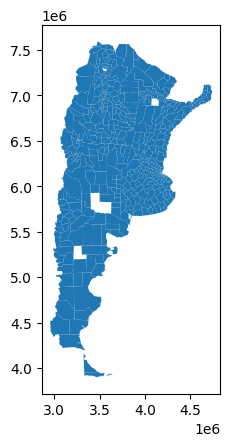

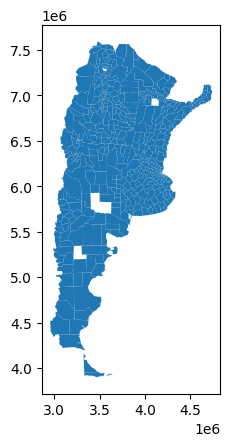

In [13]:
periodos = proc.sal.index.get_level_values(1).unique()[11:]
periodos = pd.to_datetime(periodos)
# Tomamos los datos de los salarios sobre pobleación
df_sal = pd.DataFrame(prop_st[:,:cant_peris], columns =periodos).T.resample('YE').mean()
df_sal.index = df_sal.index.year
gdf_sal = gpd.GeoDataFrame(df_sal.T, geometry = geo.reset_index().geometry)
gdf_sal.plot()


# Tomamos los datos de los puestos de trabajo sobre población
df_trab = pd.DataFrame(prop_st[:,cant_peris:], columns =periodos).T.resample('YE').mean()
df_trab.index = df_trab.index.year
gdf_trab = gpd.GeoDataFrame(df_trab.T, geometry = geo.reset_index().geometry)
gdf_trab.plot()


In [14]:
#df_sal.T.groupby(sc.y_pred).agg(['mean', 'std']).stack().round(2).to_excel("estadisticas.xlsx")
#df_trab.T.groupby(sc.y_pred).agg(['mean', 'std']).stack().round(2).to_excel("estadisticas.xlsx")

In [15]:
def graficar_mapa_clusters(gdf, clusters, geos, percentiles=(5, 95), años = [2015, 2018, 2023], promedio = False):
    """
    Graficar los clusters en un mapa utilizando GeoDataFrame y resultados de clustering.
    
    Args:
        gdf (GeoDataFrame): GeoDataFrame con los datos a graficar.
        sc (object): Objeto con los resultados del clustering.
        geos (GeoSeries): GeoSeries con las geometrías de los clusters.
    """

    valores = gdf.iloc[:,:-1].values.flatten()
    vmin = np.percentile(valores, percentiles[0])
    vmax = np.percentile(valores, percentiles[1])
    escalas_colores = ['Blues', 'Greens', 'Oranges', 'Purples', 'Reds', 'Greys']
    #escalas_colores = ['Reds', 'Reds']
    escalas_colores = (escalas_colores * ((len(np.unique(sc.y_pred)) // len(escalas_colores)) + 1))[:len(np.unique(sc.y_pred))]

    fig, ax = plt.subplots(1, 3, figsize=(20, 15))
    for idx, año in enumerate(años):
        base = geos.boundary.plot(color='black', edgecolor='black', linewidth=0.8, ax=ax[idx])
        for i in np.unique(clusters):
            gdf_ = gdf[clusters == i].copy()
            gdf_.loc[:,'prom'] = gdf_[año].mean()
            col = 'prom' if promedio else año
            gdf_.plot(col, cmap=escalas_colores[i], ax=base, vmin=vmin, vmax=vmax)
            base.set_title(año)
            base.set_axis_off()
    


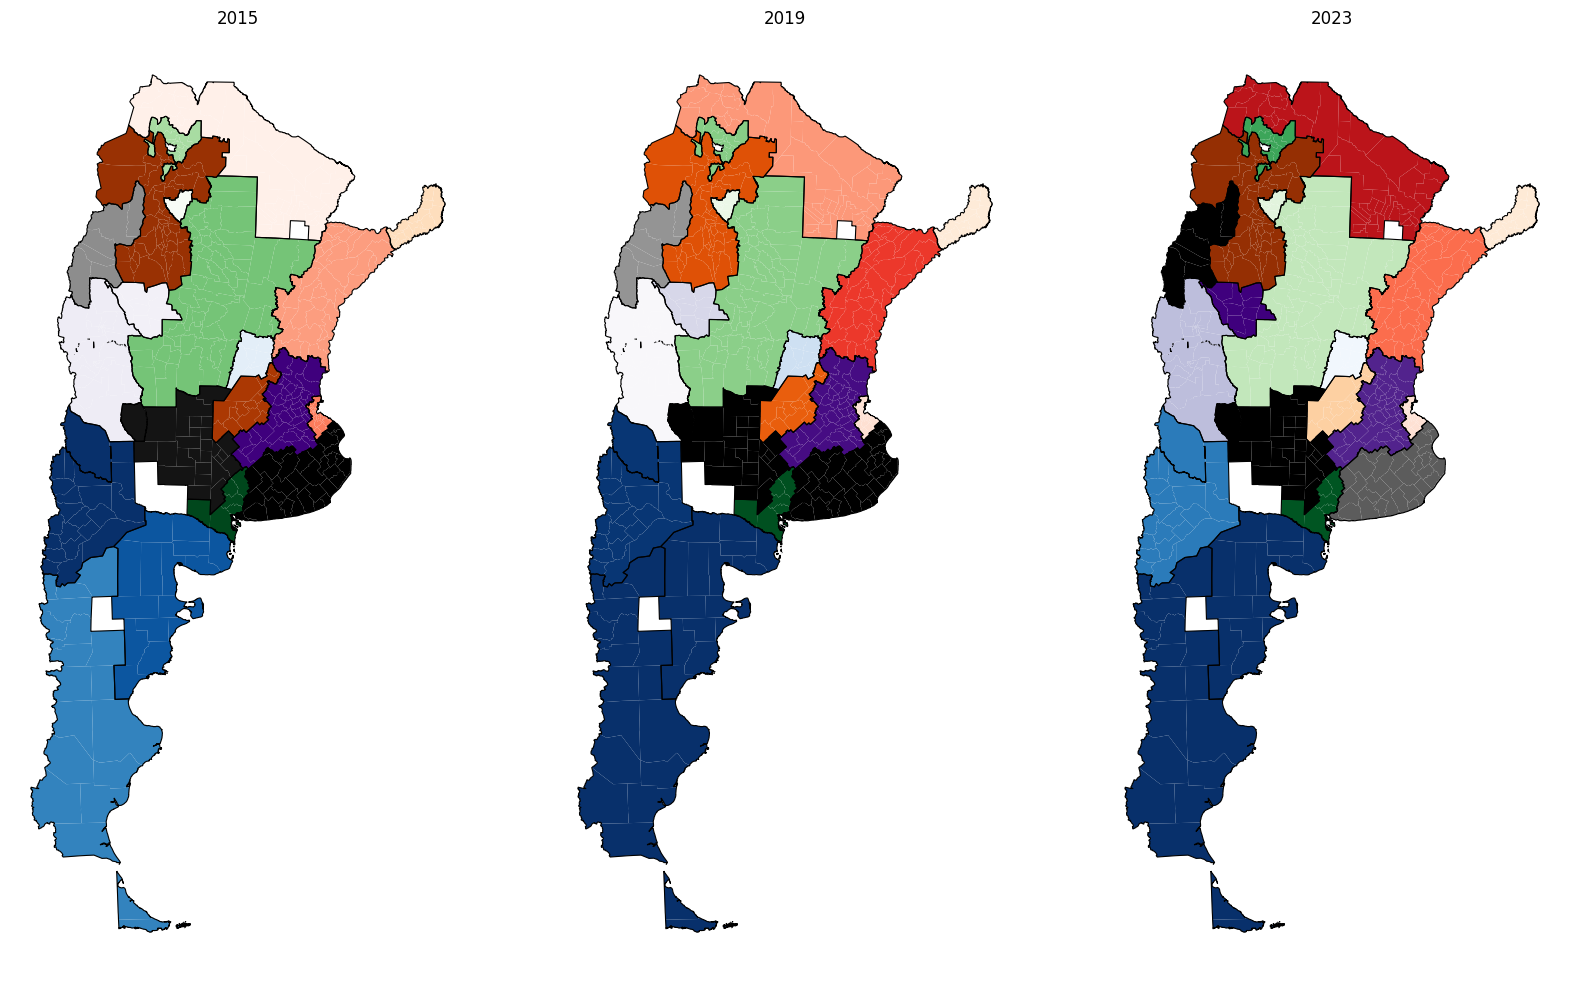

In [16]:
graficar_mapa_clusters(gdf_sal, sc.y_pred, geos,percentiles = (15,80), años = [2015, 2019, 2023], promedio = True)

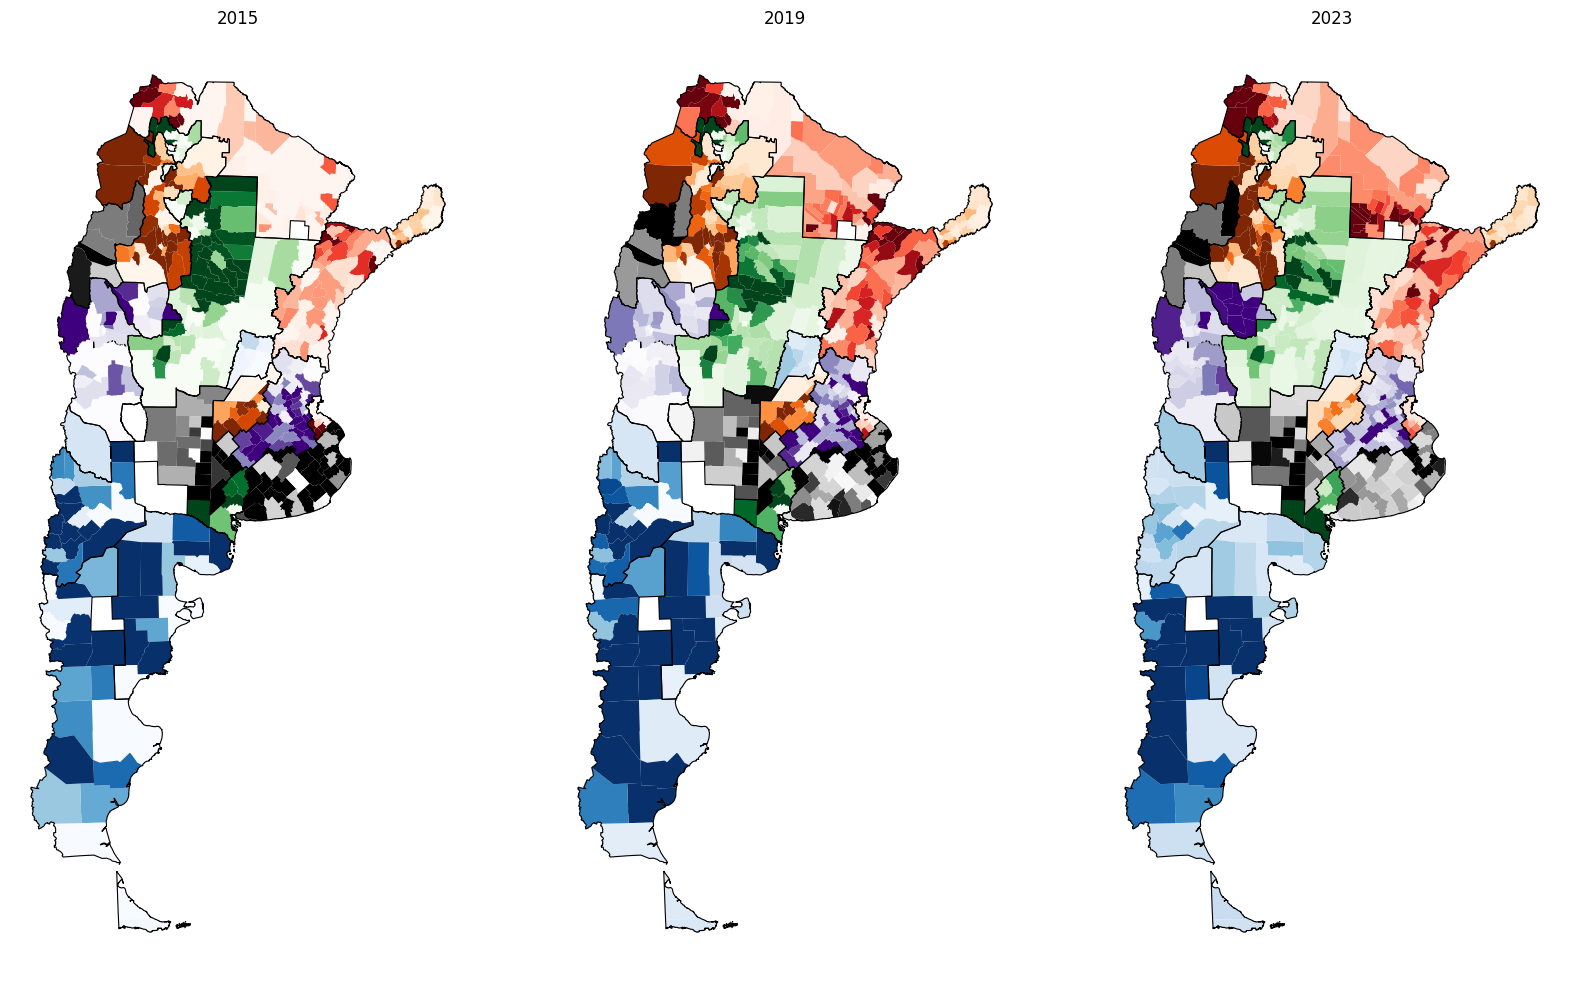

In [17]:
graficar_mapa_clusters(gdf_trab, sc.y_pred, geos,percentiles = (10,80) , años = [2015, 2019, 2023], promedio = False)

<bound method _AxesBase.set_axis_off of <Axes: >>

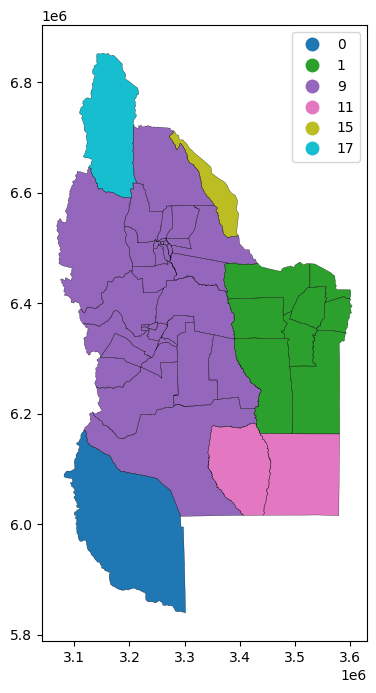

In [18]:
codiprov = proc.codiprov
filtro_region = codiprov['provincia'].isin(['Mendoza','San Juan','San Luis']).values
#filtro_region = codiprov['provincia'].isin(['Buenos Aires']).values
cuyo = geo[filtro_region]

cuyo = gpd.GeoDataFrame( prop_st[filtro_region], columns = np.array(range(cant_peris*2), str), geometry = cuyo.geometry.reset_index(drop=True) )
clusters = sc.y_pred[filtro_region]

geos_reg = []
for i in np.unique(clusters):
    g = cuyo[clusters == i].union_all()
    geos_reg.append(g)
geos_reg = gpd.GeoSeries(geos_reg)
ax = cuyo.boundary.plot(figsize = (10,8), color = 'black', edgecolor = 'black', linewidth = 0.2)
graf = cuyo.reset_index().plot(column = clusters, figsize = (10,8), categorical = True, legend = True, legend_kwds = {'loc':'upper right'}, ax = ax)

graf.set_axis_off

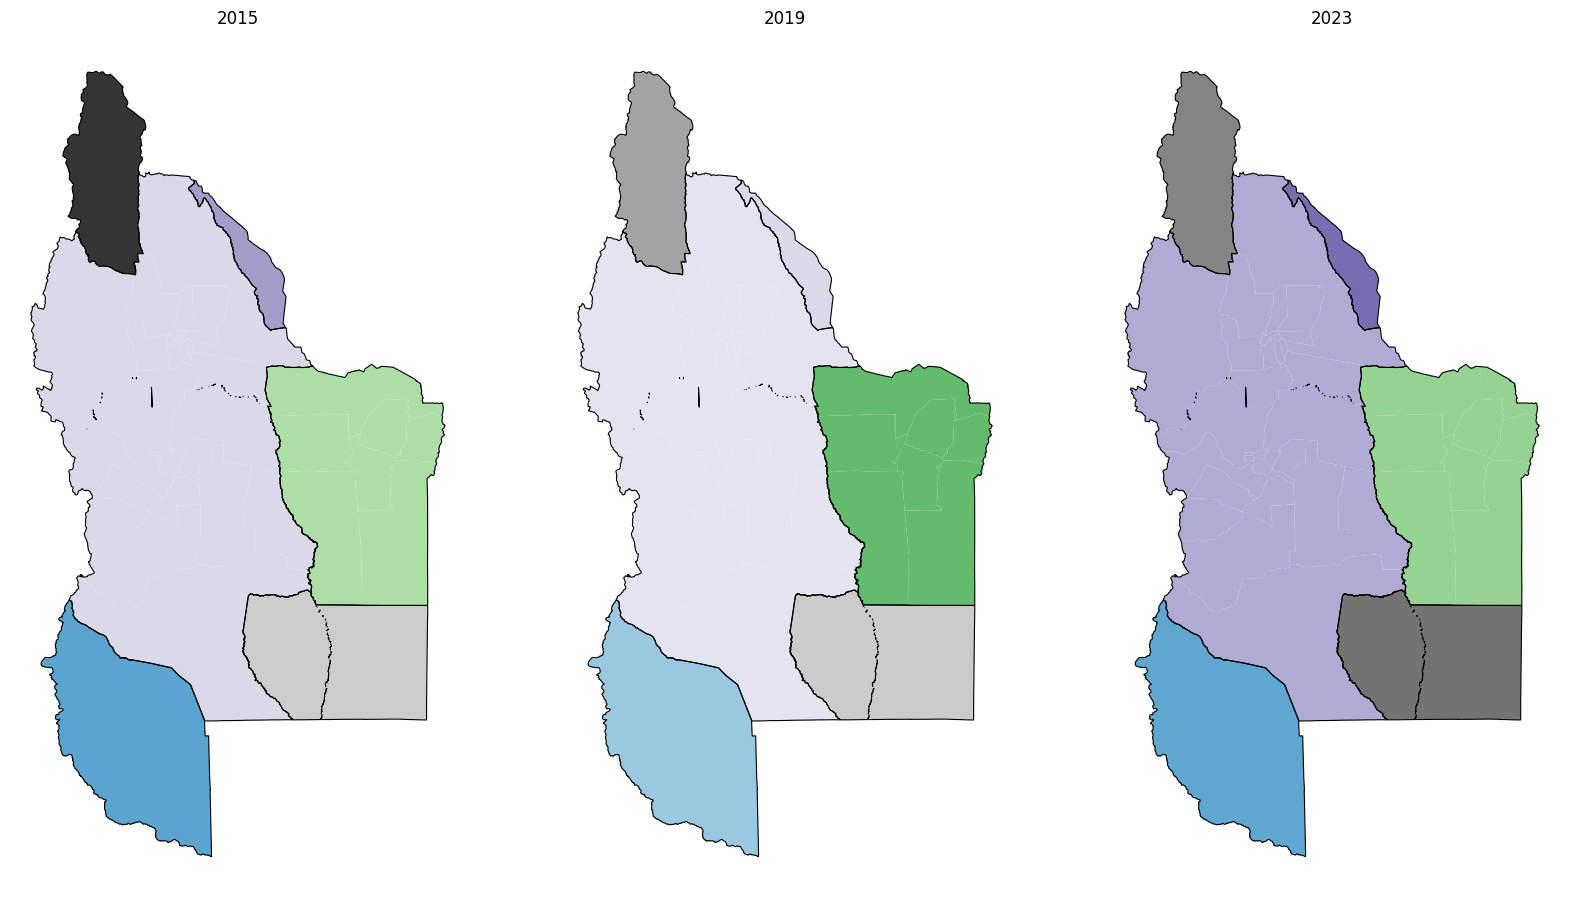

In [19]:
graficar_mapa_clusters(gdf_sal[filtro_region], sc.y_pred[filtro_region], geos_reg, percentiles=(5, 95), años=[2015, 2019, 2023], promedio=True)

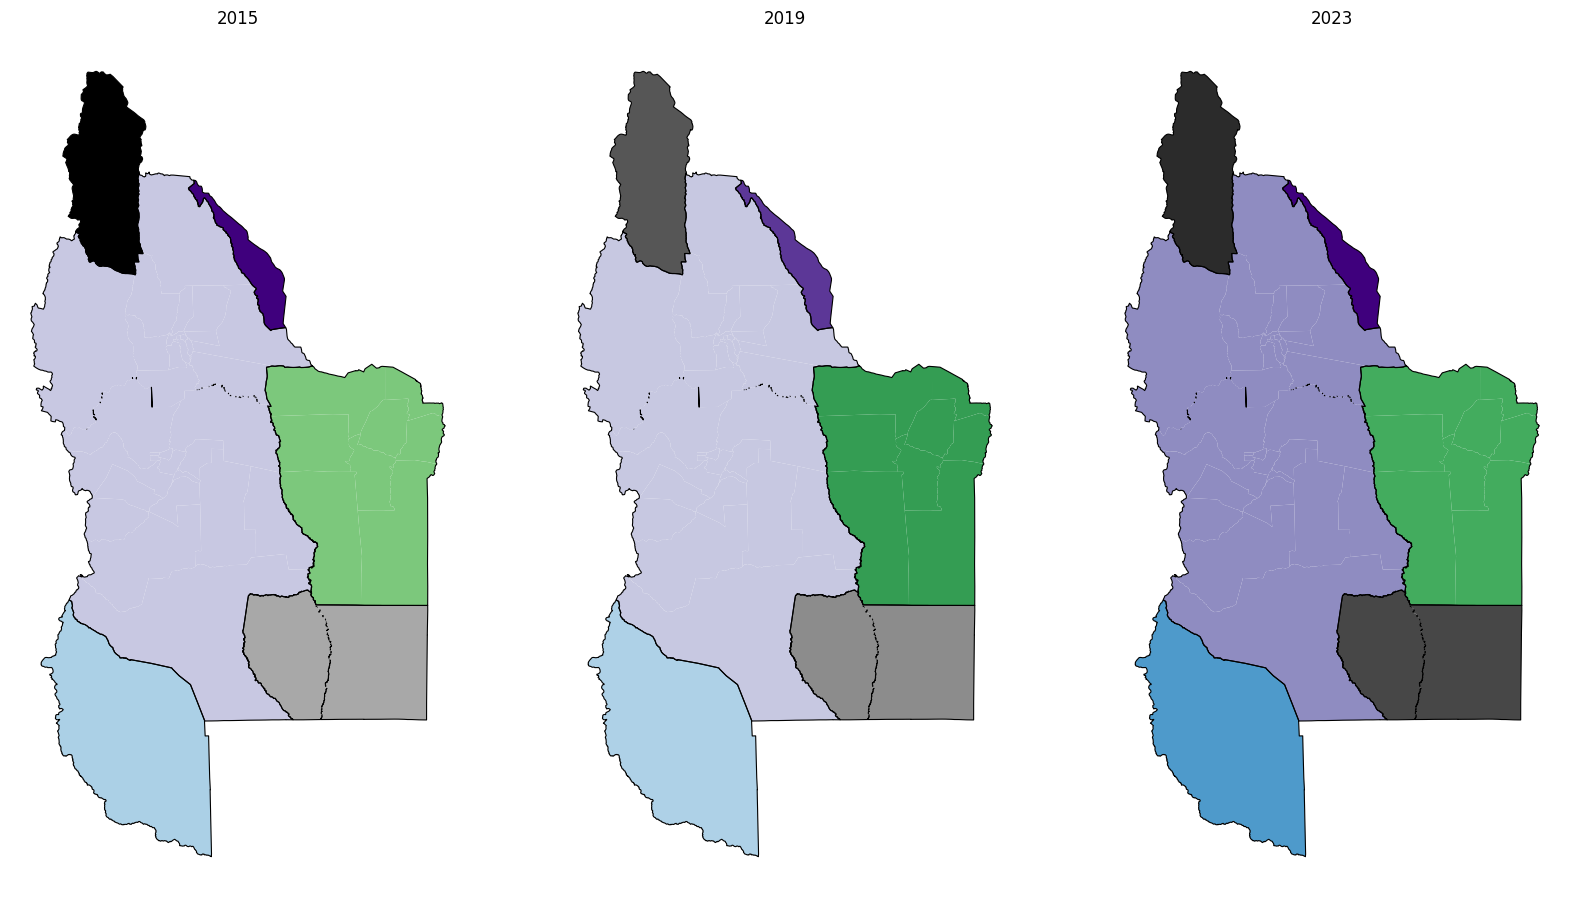

In [20]:
graficar_mapa_clusters(gdf_trab[filtro_region], sc.y_pred[filtro_region], geos_reg, percentiles=(10, 85), años=[2015, 2019, 2023], promedio=True)

In [21]:
filtro = []
for i  in np.arange(20):
    filtro.append(True if i in np.unique(clusters) else False)
stats = gdf_sal.iloc[:,:-1].groupby(sc.y_pred).agg(['mean', 'std']).stack().round(2)
stats.unstack()[np.array(filtro)].stack()

mes      2014  2015  2016  2017  2018  2019  2020  2021  2022  2023
0  mean  0.21  0.34  0.48  0.11 -0.02  0.19  0.11 -0.07  0.01  0.01
   std   0.79  0.95  0.75  0.87  0.40  0.54  0.65  0.65  1.13  1.25
1  mean -0.22 -0.14 -0.27 -0.29 -0.21 -0.19 -0.30 -0.22 -0.28 -0.31
   std   0.39  0.51  0.48  0.31  0.30  0.39  0.32  0.37  0.27  0.26
9  mean -0.32 -0.40 -0.47 -0.34 -0.26 -0.47 -0.38 -0.22 -0.23 -0.23
   std   0.28  0.32  0.29  0.22  0.24  0.10  0.26  0.19  0.24  0.50
11 mean  0.08  0.16  0.43  0.22 -0.01  0.22  0.50  0.18  0.12  0.29
   std   0.63  0.59  0.96  0.53  0.50  0.98  0.82  0.54  0.54  1.02
15 mean -0.36 -0.43 -0.31 -0.24 -0.25 -0.31 -0.25 -0.16  0.44  0.63
   std   0.28  0.20  0.36  0.23  0.30  0.46  0.23  0.23  1.19  1.08
17 mean -0.23 -0.12 -0.08 -0.05  0.13 -0.14  0.19  0.28  0.34  1.74
   std   0.20  0.26  0.27  0.10  0.32  0.28  0.41  0.35  0.45  2.75

In [22]:
stats = gdf_sal[filtro_region].iloc[:,:-1].groupby(clusters).agg(['mean', 'std']).stack().round(2)
#stats.to_excel("estadisticas_cuyo.xlsx")